# 붓꽃 데이터로 시작하는 EDA

## 오늘의 질문
**꽃의 길이와 너비를 보면 붓꽃의 품종을 구분할 단서를 찾을 수 있을까요?**

이론에서는 카페 매출의 차이를 살펴봤습니다. 이번에는 꽃의 **품종에 따른 측정값의 차이**를 살펴봅니다.

오늘의 목표는 코드를 외우는 것이 아니라, 결과를 보고 **관찰한 사실과 다음에 확인할 질문**을 말하는 것입니다.

**진행 순서:** 질문과 데이터 이해 → 구조와 품질 확인 → 숫자 요약 → 분포 → 품종별 산점도 → 정리

- 각 코드 셀은 위에서부터 순서대로 실행하세요.

## 1. 어떤 데이터인가요?

**한 행은 붓꽃 표본 하나를 측정한 기록입니다.** 같은 꽃의 네 가지 측정값과 실제 품종이 함께 기록되어 있습니다.

| 항목 | 의미 | 단위 |
|---|---|---|
| sepal length (cm) | 꽃받침 길이 | cm |
| sepal width (cm) | 꽃받침 너비 | cm |
| petal length (cm) | 꽃잎 길이 | cm |
| petal width (cm) | 꽃잎 너비 | cm |
| species | 실제 품종: setosa, versicolor, virginica | 범주 |

꽃받침과 꽃잎은 꽃의 서로 다른 부분입니다. **길이와 너비는 측정값**, **품종은 구분하려는 대상**입니다.

이 데이터는 scikit-learn에 포함된 교육용 데이터이며, 붓꽃 표본 150개의 기록을 담고 있습니다. 이 표만으로 모든 지역이나 자연 속 붓꽃의 비율을 알 수는 없습니다.

![iris](iris.png)

### 준비: 도구와 데이터 불러오기

다음 셀은 표와 그래프를 만드는 도구, 한글 글꼴, 데이터를 준비합니다. **설정 코드를 이해하거나 외울 필요는 없습니다.** 실행 후 첫 다섯 행을 확인하세요.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.datasets import load_iris

sns.set_style("whitegrid")

font_candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic"]
available_fonts = {f.name for f in fm.fontManager.ttflist}
korean_font = next((f for f in font_candidates if f in available_fonts), None)

if korean_font:
    plt.rcParams["font.family"] = korean_font
    plt.rcParams["font.sans-serif"] = [korean_font] + plt.rcParams["font.sans-serif"]
else:
    print("한글 폰트를 찾지 못했습니다. '맑은 고딕' 또는 '나눔고딕'을 설치한 뒤 커널을 재시작하세요.")

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. 기록은 얼마나 있고, 빠진 값은 없나요?

**왜 볼까요?** 데이터의 크기와 누락 여부, 품종별 기록 수를 알아야 비교 결과를 해석할 수 있습니다.

info() 메소드를 통해 데이터의 형태를 확인해 봅시다.

In [3]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


None

**확인:** 이 데이터는 총 150개의 데이터가 있고, 결측 값은 없습니다. 수치들은 모두 실수형(float64)입니다.

## 3. 숫자로 전체 모습을 요약해 볼까요?

**왜 볼까요?** 값의 대략적인 크기와 범위를 먼저 파악합니다.

describe() 메소드는 수치형 데이터의 통계 정보들을 한 눈에 확인할 수 있는 메소드입니다.

- count : 데이터 수
- mean : 평균
- std : 분산
- min/max : 최솟값/최댓값
- 25%/50%/75% : 데이터를 크기 순으로 정렬 했을 때 각 % 지점의 데이터 수치

평균 하나만으로는 값들이 어떻게 퍼져 있는지 알 수 없습니다.

In [4]:
display(df.describe())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### 품종별로 나누면 어떤 차이가 보일까요?

전체 평균에 숨겨진 차이를 찾아봅니다. **평균이 다르더라도 개별 꽃의 측정값은 서로 겹칠 수 있습니다.**

In [9]:
display(df.groupby("species", observed=True).mean().round(2))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


## 4. 꽃잎 길이의 분포 확인

**히스토그램**은 값을 구간으로 나누고 각 구간에 속한 기록 수를 보여줍니다.

- 가로축: 꽃잎 길이(cm)
- 세로축: 해당 구간의 꽃 표본 수
- 지금은 세 품종을 모두 합쳐서 봅니다.

**찾을 것:** 값이 많이 모인 구간, 드문 구간, 떨어져 보이는 무리

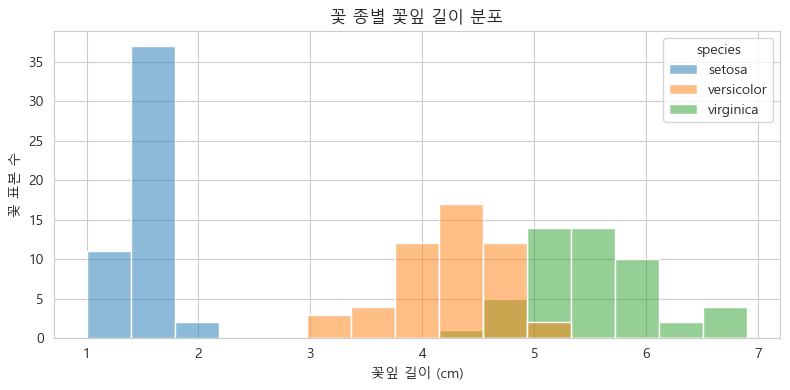

In [11]:
# 보고 싶은 종류를 선택해 주세요.
# ["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"]
x = "petal length (cm)"

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x=x, hue="species", bins=15, multiple="layer", alpha=0.5)
plt.xlabel("꽃잎 길이 (cm)")
plt.ylabel("꽃 표본 수")
plt.title("꽃 종별 꽃잎 길이 분포")
plt.tight_layout()
plt.show()

## 5. 두 측정값을 함께 보면 품종을 구분할 수 있을까요?

**산점도**에서는 점 하나가 꽃 표본 하나를 나타냅니다.

- 가로축: 꽃잎 길이(cm)
- 세로축: 꽃잎 너비(cm)
- 점의 색과 모양: 실제 품종

**찾을 것:** 떨어져 있는 품종과 서로 겹치는 품종

색은 이미 기록된 실제 품종을 보여줍니다. 모델이 예측한 결과가 아닙니다.

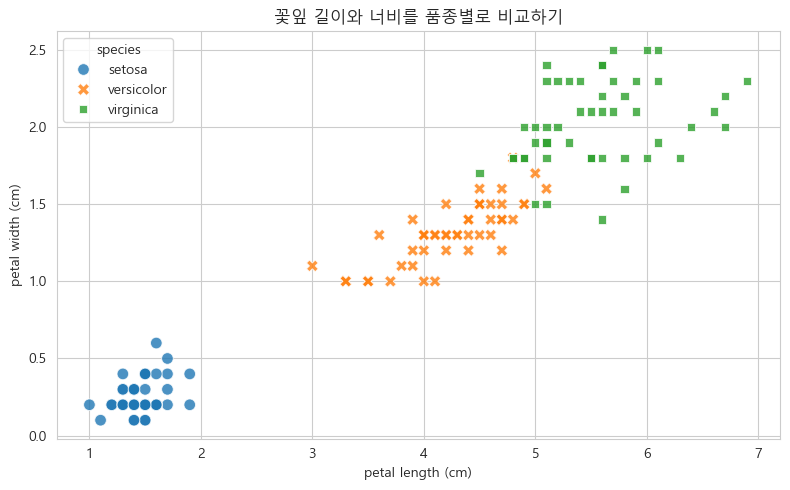

In [12]:
# 보고 싶은 종류를 선택해 주세요.
# ["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"]
x = "petal length (cm)"
y = "petal width (cm)"

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=x, y=y,
                hue="species", style="species", s=70, alpha=0.8)
plt.xlabel(x)
plt.ylabel(y)
plt.title("꽃잎 길이와 너비를 품종별로 비교하기")
plt.tight_layout()
plt.show()

### 결과를 해석해 보세요

1. 다른 두 품종과 뚜렷하게 떨어져 있는 품종은 무엇인가요?
2. 어떤 두 품종은 일부 영역에서 겹치나요?
3. 겹치는 위치에서 새 꽃이 관찰되면 품종을 자신 있게 판단할 수 있을까요?
4. 꽃잎이 긴 꽃은 대체로 너비도 큰가요? 길이가 너비를 ‘증가시킨다’고 말할 수 있을까요?

## 6. 정보 사이의 상관관계 찾기

상관계수는 두 숫자 항목의 **직선적인 관계**를 요약합니다. +1에 가까우면 함께 커지는 경향, −1에 가까우면 한쪽이 커질 때 다른 쪽이 작아지는 경향이 강합니다. 0에 가깝다고 모든 관계가 없는 것은 아닙니다.

**질문:** 꽃잎 길이와 너비는 어떤 관계인가요?

이 표는 모든 품종을 합친 결과입니다. 품종별로 나누면 관계의 크기가 달라질 수 있습니다. 상관관계는 인과관계나 특정 항목을 삭제해야 한다는 근거가 되지는 않습니다.

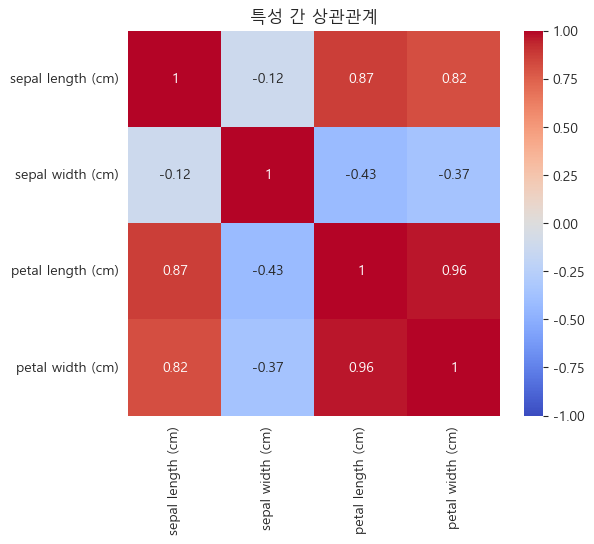

In [18]:
# 상관관계 히트맵: 특성 간 선형 상관관계의 강도와 방향을 확인
features = ["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"]
corr = df[features].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("특성 간 상관관계")
plt.show()

상관관계가 높게 나타난 컬럼끼리 정말 상관관계가 나타나는지 산점도를 직접 그려봅시다.

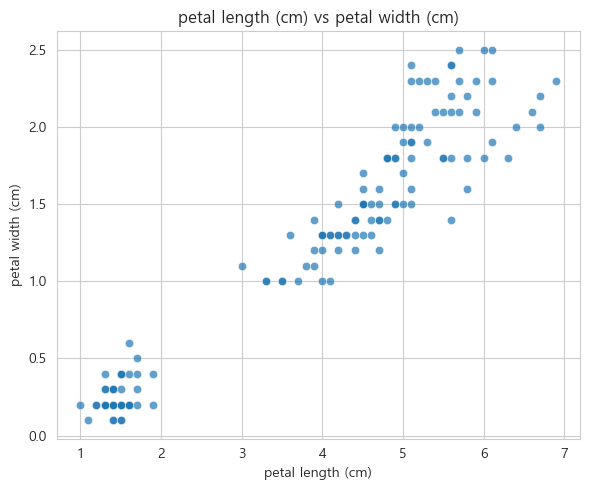

In [19]:
# 상관관계를 확인하고 싶은 두 컬럼을 선택해 주세요.
# ["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"]
x = "petal length (cm)"
y = "petal width (cm)"

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x=x, y=y, alpha=0.7)
plt.xlabel(x)
plt.ylabel(y)
plt.title(f"{x} vs {y}")
plt.tight_layout()
plt.show()